# Análise de Lucro e Fluxo de Caixa de Empresas listadas nas bolsas NYSE e NASDAQ

### Objetivos:

1. Analisar o comportamento das 50 empresas que mais lucraram todos os anos
entre 2019 e 2024.

2. Fazer Overview geral dos lucros das empresas segmentando pelos seus Setores

3. Fazer Overviews da DFC (operacional, investimento, financiamento e líquido) das top 50 empresas

4. Investigar se tais empresas converteram seus lucros em Fluxo de Caixa Operacional.

5. Analisar o comportamento do Fluxo de Caixa Financiamento das empresas selecionadas, a fim de compreender o quanto as empresas estão comprometidas com capital de terceiros e se pagam dividendos.

6. Destacar empresas financeiramente estáveis e averiguar informações adicionais no mercado financeiro.

7. Conectar à uma API do mercado financeiro (Marketstack) para retornar informações adicionais como nome completo das empresas, segmentação do setor, bolsa onde opera seus ativos, preço de abertura e fechamento do ativo


## Análise Exploratória Inicial e pequenas transformações

In [5]:
import kagglehub
import pandas as pd
import os

# Puxa o dataset direto do Kaggle
path = kagglehub.dataset_download("eu1234/stocks-quarter-cashflow-statements-04-2019-05-2024")

#Lista os arquivos da pasta
files = os.listdir(path)

# Escolhe o segundo arquivo da Pasta (tem um em parquet e outro em csv)
file_path = os.path.join(path, files[1])

# Lê o arquivo em CSV
df = pd.read_csv(file_path, on_bad_lines='warn', engine='python')

# Mostra as primeiras 5 linhas
df.head()

,Unnamed: 0,Date,Ticker,Sector,Net Income,Depreciation & Amortization,Share-Based Compensation,Other Operating Activities,Operating Cash Flow,Operating Cash Flow Growth %,...,Other Financing Activities,Financing Cash Flow,Net Cash Flow,Free Cash Flow,Free Cash Flow Growth %,Free Cash Flow Margin %,Free Cash Flow Per Share,Exchange Rate Effect,Share Repurchases,Common Stock Issued
0,5775,2024-04-30,A,Healthcare,308.0,63.0,31.0,-69.0,333.0,-16.33,...,-1.0,-291.0,-76.0,230.0,-32.55,14.62,0.79,-9.0,NaN,NaN
1,5776,2024-01-31,A,Healthcare,348.0,62.0,44.0,31.0,485.0,63.85,...,-25.0,-240.0,157.0,395.0,79.55,23.82,1.35,7.0,NaN,NaN
2,5777,2023-10-31,A,Healthcare,475.0,62.0,14.0,-35.0,516.0,15.18,...,-2.0,-201.0,261.0,432.0,14.29,25.59,1.49,-14.0,NaN,NaN
3,5778,2023-07-31,A,Healthcare,111.0,71.0,29.0,351.0,562.0,72.39,...,-6.0,-322.0,154.0,481.0,97.13,28.77,1.64,3.0,NaN,NaN
4,5779,2023-04-30,A,Healthcare,302.0,71.0,24.0,1.0,398.0,40.64,...,-1.0,-390.0,-75.0,341.0,55.71,19.86,1.15,-6.0,NaN,NaN


In [6]:
# Listagem das Colunas
df.columns

Index(['Unnamed: 0', 'Date', 'Ticker', 'Sector', 'Net Income',
       'Depreciation & Amortization', 'Share-Based Compensation',
       'Other Operating Activities', 'Operating Cash Flow',
       'Operating Cash Flow Growth %', 'Capital Expenditures', 'Acquisitions',
       'Change in Investments', 'Other Investing Activities',
       'Investing Cash Flow', 'Dividends Paid', 'Share Issuance / Repurchase',
       'Debt Issued / Paid', 'Other Financing Activities',
       'Financing Cash Flow', 'Net Cash Flow', 'Free Cash Flow',
       'Free Cash Flow Growth %', 'Free Cash Flow Margin %',
       'Free Cash Flow Per Share', 'Exchange Rate Effect', 'Share Repurchases',
       'Common Stock Issued'],
      dtype='object')

In [7]:
# Troca de nome da primeira coluna
df = df.rename(columns={
    'Unnamed: 0': 'Code'
})

In [8]:
# Checagem de duplicados na coluna Code

df[df['Code'].duplicated(keep=False)]

,Code,Date,Ticker,Sector,Net Income,Depreciation & Amortization,Share-Based Compensation,Other Operating Activities,Operating Cash Flow,Operating Cash Flow Growth %,...,Other Financing Activities,Financing Cash Flow,Net Cash Flow,Free Cash Flow,Free Cash Flow Growth %,Free Cash Flow Margin %,Free Cash Flow Per Share,Exchange Rate Effect,Share Repurchases,Common Stock Issued
137,0,2024-03-31,AAPL,Technology,23636.00,2836.00,2964.00,-6746.00,22690.00,-20.55,...,-370.00,-30433.00,-8053.00,20694.00,-19.30,22.80,1.34,NaN,NaN,NaN
518,0,2024-05-31,ACCD,Healthcare,-27.59,10.39,15.31,-5.23,-7.12,NaN,...,NaN,2.07,2.99,-9.08,NaN,-8.22,-0.12,NaN,NaN,NaN
840,0,2024-05-31,ACN,Technology,1932.00,521.31,473.93,214.58,3142.00,-4.48,...,-38.43,-216.90,416.11,3018.00,-4.13,18.33,4.80,-58.02,NaN,NaN
1021,0,2024-05-31,ADBE,Technology,1573.00,233.00,467.00,-333.00,1940.00,-9.30,...,-139.00,-642.00,1406.00,1899.00,-5.90,35.77,4.23,-3.00,NaN,NaN
4563,0,2024-05-31,APOG,Industrials,31.01,12.87,2.70,-41.13,5.45,-74.38,...,-4.87,-4.93,-6.85,-1.74,NaN,-0.52,-0.08,-0.05,NaN,NaN
6923,0,2024-05-31,AYI,Industrials,113.90,22.90,11.80,3.90,152.50,-7.63,...,-1.00,-21.50,120.10,140.50,-7.99,14.51,4.56,1.00,NaN,NaN
7033,0,2024-05-31,AZZ,Industrials,-36.80,20.32,2.54,9.48,71.94,53.42,...,-313.49,-38.54,6.20,44.55,49.20,10.78,1.67,0.17,NaN,NaN
7367,0,2024-05-31,BB,Technology,-42.00,13.00,8.00,6.00,-15.00,NaN,...,NaN,1.00,-40.00,-16.00,NaN,-11.11,-0.03,0.00,NaN,NaN
10032,0,2024-05-31,BSET,Consumer Cyclical,-7.20,2.63,NaN,10.39,5.82,-0.51,...,NaN,-2.06,2.04,4.21,135.89,5.05,0.48,-0.01,NaN,NaN
10677,0,2024-05-31,BYRN,Industrials,2.08,0.55,0.86,-1.55,1.93,91.58,...,-0.80,-0.94,0.61,1.41,32.24,6.96,0.06,0.14,NaN,NaN


In [9]:
# Tipagem das Colunas, verificação de valores nulos e contagem de linhas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68529 entries, 0 to 68528
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Code                          68529 non-null  int64  
 1   Date                          68529 non-null  object 
 2   Ticker                        68529 non-null  object 
 3   Sector                        68509 non-null  object 
 4   Net Income                    68400 non-null  float64
 5   Depreciation & Amortization   64653 non-null  float64
 6   Share-Based Compensation      60386 non-null  float64
 7   Other Operating Activities    68354 non-null  float64
 8   Operating Cash Flow           67297 non-null  float64
 9   Operating Cash Flow Growth %  40679 non-null  float64
 10  Capital Expenditures          64538 non-null  float64
 11  Acquisitions                  49999 non-null  float64
 12  Change in Investments         49929 non-null  float64
 13  O

In [10]:
# Contagem de valores nulos por coluna
df.isnull().sum()

,0
Code,0
Date,0
Ticker,0
Sector,20
Net Income,129
Depreciation & Amortization,3876
Share-Based Compensation,8143
Other Operating Activities,175
Operating Cash Flow,1232
Operating Cash Flow Growth %,27850


In [11]:
# Contagem única de empresas no Dataset inteiro
Empresas = df['Ticker'].nunique()

print(f"Existem {Empresas} empresas dentro da análise")

Existem 3686 empresas dentro da análise


In [12]:
# Contagem única de Setores no Dataset
Setores = ', '.join(df['Sector'].dropna().unique())

print(f"Os setores {Setores} fazem parte da análise")

Os setores Healthcare, Basic Materials, Industrials, Technology, Consumer Cyclical, Real Estate, Financial Services, Energy, Consumer Defensive, Communication Services, Utilities fazem parte da análise


In [13]:
# Tabela com as empresas e seus respectivos setores

empresas_e_setores = df[['Ticker', 'Sector']].drop_duplicates()
empresas_e_setores

,Ticker,Sector
0,A,Healthcare
20,AA,Basic Materials
40,AAL,Industrials
60,AAN,Industrials
77,AAOI,Technology
...,...,...
68437,ZURA,Healthcare
68449,ZVRA,Healthcare
68469,ZWS,Industrials
68489,ZYME,Healthcare


In [14]:
# Transformando a coluna de data em datetime
df['Date'] = pd.to_datetime(df['Date'])

# Criando colunas de ano, mês e trimestre
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

In [15]:
# Data da última publicação das demonstrações financeiras
ultima_data = df['Date'].max().strftime("%d-%m-%Y")

print(f"A última demonstração foi publicada em {ultima_data}")

A última demonstração foi publicada em 30-06-2024


## Análise de Lucro das Empresas

De acordo com as normas de compliance do GAAP (Generally Accepted Accounting Principles), a SEC (agência de regulação do mercado financeiro dos EUA) prevê a obrigatoriedade de publicar as demonstrações financeiras de cada empresa listada nas bolsas dos EUA

Portanto, é necessário filtrar e descartar todas as empresas que não divulgaram suas informações de Lucro e Demonstração de Fluxo de Caixa (DFC)

Link útil sobre a GAAP e SEC: https://www.investopedia.com/terms/g/gaap.asp

In [16]:
# Filtra as colunas de Lucro e de DFC que não estão vazias
df_filtrado = df.loc[~df[['Net Income','Operating Cash Flow', 'Investing Cash Flow', 'Financing Cash Flow']].isna().any(axis=1)]

df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66288 entries, 0 to 68528
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Code                          66288 non-null  int64         
 1   Date                          66288 non-null  datetime64[ns]
 2   Ticker                        66288 non-null  object        
 3   Sector                        66269 non-null  object        
 4   Net Income                    66288 non-null  float64       
 5   Depreciation & Amortization   64534 non-null  float64       
 6   Share-Based Compensation      60187 non-null  float64       
 7   Other Operating Activities    66245 non-null  float64       
 8   Operating Cash Flow           66288 non-null  float64       
 9   Operating Cash Flow Growth %  40490 non-null  float64       
 10  Capital Expenditures          64531 non-null  float64       
 11  Acquisitions                  499

In [17]:
df_filtrado.isnull().sum()

,0
Code,0
Date,0
Ticker,0
Sector,19
Net Income,0
Depreciation & Amortization,1754
Share-Based Compensation,6101
Other Operating Activities,43
Operating Cash Flow,0
Operating Cash Flow Growth %,25798


## Overview das empresas

In [18]:
# Soma da coluna de Net Income por ano e empresa
df_agrupado = df_filtrado.groupby(['Year', 'Ticker'], as_index=False)['Net Income'].sum()

# Coluna de Lucro Ou Prejuizo, onde Neutro são as empresas que apresentaram lucro 0
df_agrupado['LucroOuPrejuizo'] = df_agrupado['Net Income'].apply(lambda x: 'Lucro' if x > 0 else ('Prejuízo' if x < 0 else 'Neutro'))

# Resumo numa tabela dinâmica da quantidade de empresas que tiveram lucro, prejuízo ou foram neutras por ano
resumo = df_agrupado.groupby(['Year', 'LucroOuPrejuizo']).size().unstack(fill_value=0)

print('Overview das empresas (Neutro são as empresas que apresentaram lucro 0)\n')
resumo

Overview das empresas (Neutro são as empresas que apresentaram lucro 0)



LucroOuPrejuizo,Lucro,Neutro,Prejuízo
Year,,,
2017,0,0,1
2018,0,0,1
2019,2020,5,867
2020,1893,12,1389
2021,2296,4,1156
2022,2295,3,1243
2023,2295,0,1256
2024,2243,0,1251


## Gráfico com a quantidade de empresas que lucraram por ano

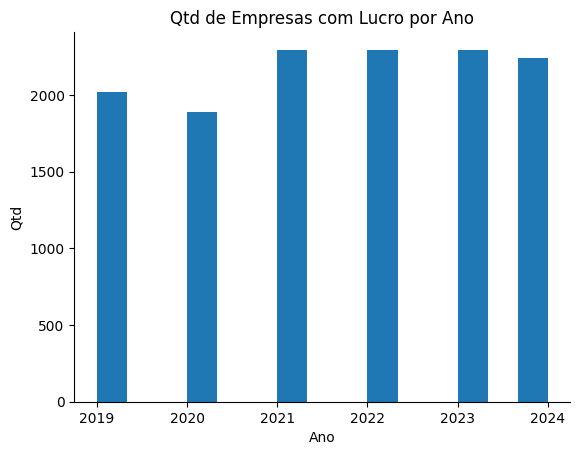

In [19]:
# Filtro das empresas que tiveram lucro
empresas_com_lucro = df_agrupado[df_agrupado['Net Income'] > 0]

# Gráfico para exemplificar
from matplotlib import pyplot as plt
empresas_com_lucro['Year'].plot(kind='hist', bins=15, title='Qtd de Empresas com Lucro por Ano')
plt.xlabel('Ano')
plt.ylabel('Qtd')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [20]:
# Lista das empresas que tiveram Lucro por Ano
empresas_lucro_por_ano = (
    df_agrupado[df_agrupado['Net Income'] > 0]
    .groupby('Year')['Ticker']
    .unique()
)

In [21]:
anos_disponiveis = df_agrupado['Year'].unique()

# Conjuntos de empresas por ano com lucro
sets_por_ano = [
    set(empresas) for empresas in empresas_lucro_por_ano
]

# Lista das empresas que tiveram Lucro todos os anos
empresas_lucro_todos_anos = set.intersection(*sets_por_ano)
empresas_lucrativas = pd.DataFrame(empresas_lucro_todos_anos)

# Contagem de empresas que tiveram lucro todos os anos
contagem_empresas = len(empresas_lucro_todos_anos)

print(f"Existem {contagem_empresas} empresas que tiveram lucro em todos os anos.")

empresas_lucrativas = empresas_lucrativas.rename(columns={0: 'Ticker'})

Existem 1250 empresas que tiveram lucro em todos os anos.


### Selecionando as top 50 empresas que lucraram todos os anos

In [22]:
top = empresas_lucrativas.merge(df_agrupado, on='Ticker', how='left')

top_50_empresas = top.groupby(['Ticker', 'Year'], as_index=False)['Net Income'].sum()

top_50_empresas_com_lucro = top_50_empresas.pivot_table(
    index = 'Ticker',
    columns = 'Year',
    values = 'Net Income',
    aggfunc = 'sum'
)

top_50_empresas_com_lucro['Total'] = top_50_empresas_com_lucro.sum(axis=1)

top_50_empresas_com_lucro = top_50_empresas_com_lucro.sort_values(by='Total', ascending=False)

top_50_empresas_com_lucro = top_50_empresas_com_lucro.nlargest(50, 'Total')

top_50_empresas_com_lucro

Year,2019,2020,2021,2022,2023,2024,Total
Ticker,,,,,,,
PKX,1123152.0,1581208.0,6606728.0,3157536.0,1698202.0,540715.0,14707541.0
TM,1708838.0,1795366.0,3093419.0,2432914.0,4499534.0,997691.0,14527762.0
SONY,569547.0,975555.0,837795.0,1035994.0,922549.0,189005.0,4530445.0
HMC,485288.0,414560.0,795492.0,708067.0,937856.0,237565.0,3578828.0
TSM,292554.0,510160.0,592358.0,992923.0,851740.0,225485.0,3465220.0
IX,244319.0,200396.0,261710.0,312714.0,298157.0,126927.0,1444223.0
BABA,146101.0,158949.0,72721.0,32752.0,99987.0,3270.0,513780.0
AAPL,45966.0,63930.0,100555.0,95171.0,100913.0,23636.0,430171.0
MSFT,35514.0,51310.0,71185.0,67449.0,82541.0,21939.0,329938.0


Na tabela dinâmica, vemos que alguns valores estão duplicados, ou seja, 2 empresas têm os mesmos lucros em todos os anos, algo bem fora do comum

In [23]:
# Remoção dos Lucros duplicados
original = len(top_50_empresas_com_lucro)

top_50_empresas_com_lucro = top_50_empresas_com_lucro.drop_duplicates(subset='Total')

print(f'{original - len(top_50_empresas_com_lucro)} duplicatas removidas')

top_50_empresas_com_lucro

1 duplicatas removidas


Year,2019,2020,2021,2022,2023,2024,Total
Ticker,,,,,,,
PKX,1123152.0,1581208.0,6606728.0,3157536.0,1698202.0,540715.0,14707541.0
TM,1708838.0,1795366.0,3093419.0,2432914.0,4499534.0,997691.0,14527762.0
SONY,569547.0,975555.0,837795.0,1035994.0,922549.0,189005.0,4530445.0
HMC,485288.0,414560.0,795492.0,708067.0,937856.0,237565.0,3578828.0
TSM,292554.0,510160.0,592358.0,992923.0,851740.0,225485.0,3465220.0
IX,244319.0,200396.0,261710.0,312714.0,298157.0,126927.0,1444223.0
BABA,146101.0,158949.0,72721.0,32752.0,99987.0,3270.0,513780.0
AAPL,45966.0,63930.0,100555.0,95171.0,100913.0,23636.0,430171.0
MSFT,35514.0,51310.0,71185.0,67449.0,82541.0,21939.0,329938.0


In [24]:
# Lista das Top 50 empresas

top_50 = top_50_empresas_com_lucro.index.to_list()

df_top_50 = pd.DataFrame(top_50, columns=['Ticker'])

In [25]:
df_filtrado_2 = df_top_50.merge(df_filtrado, on='Ticker', how='left')

### DF Top 50 em formato tabela normal

In [26]:
top_50_sem_total = top_50_empresas_com_lucro.drop(columns='Total')

# Converte de volta para formato tabular (long)
top_50_tabular = top_50_sem_total.reset_index().melt(
    id_vars='Ticker',
    var_name='Year',
    value_name='Net Income'
)

## Análise de Lucro ou Prejuízo dos Setores

## Overview por Ano e Setor (Considerando todas as empresas)

In [27]:
# Agrupamento por Setor e Ano
df_Setores = df_filtrado.groupby(['Year', 'Sector'], as_index=False)['Net Income'].sum()

# Tabela Dinâmica para ver a performance de cada setor por ano
tb_dinamica = df_Setores.pivot_table(
    index = 'Sector',
    columns = 'Year',
    values = 'Net Income',
    aggfunc = 'sum'
)

# Remoção dos anos 2017 e 2018 por falta de dados
tb_dinamica = tb_dinamica.drop(columns=[2017, 2018])

# Adição da coluna de total
tb_dinamica['Total'] = tb_dinamica.sum(axis=1)

# Classificação em ordem decrescente
tb_dinamica = tb_dinamica.sort_values(by='Total', ascending=False)

# Formatação dos dados para apenas 2 casas decimais
tb_dinamica_formatada = tb_dinamica.map(lambda x: f"{x:,.2f}")

# Display da tabela dinâmica
tb_dinamica_formatada

Year,2019,2020,2021,2022,2023,2024,Total
Sector,,,,,,,
Basic Materials,"1,142,512.36","1,598,274.08","6,714,091.52","3,278,760.41","1,763,535.92","554,283.96","15,051,458.25"
Financial Services,"656,656.53","578,481.61","1,025,101.10","789,316.80","1,062,556.00","324,127.28","4,436,239.32"
Healthcare,"204,321.17","364,163.06","758,289.65","537,204.09","467,433.70","37,401.30","2,368,812.97"
Technology,"-1,716,134.70","1,641,228.76","2,990,095.08","-559,980.01","-171,361.33","-14,758.73","2,169,089.07"
Communication Services,"139,682.11","120,508.77","250,906.26","158,727.45","206,149.27","62,632.09","938,605.95"
Energy,"39,537.55","-221,624.96","189,688.21","424,005.50","343,072.27","68,628.50","843,307.07"
Industrials,"113,370.80","54,907.70","186,613.16","215,813.48","217,513.30","52,862.58","841,081.02"
Consumer Defensive,"54,124.09","109,301.69","110,392.27","120,487.19","133,426.12","48,990.53","576,721.89"
Utilities,"31,764.62","35,394.13","30,694.08","42,955.72","66,133.72","20,943.93","227,886.20"


## Setor com mais empresas com lucro por ano

In [28]:
# Agrupa o dataset por Setor, Ano e Empresa, somando a coluna lucro líquido (Net Income)
df_lucro = df_filtrado.groupby(['Sector', 'Year', 'Ticker'], as_index=False)['Net Income'].sum()

# Filtra somente empresas com Lucro
df_lucro = df_lucro[df_lucro['Net Income'] > 0]

# Agrupa por Setor e ano, contando unicamente as empresas
anos_com_lucro = df_lucro.groupby(['Sector', 'Year'])['Ticker'].nunique().reset_index()

# Para cada ano, pega o setor com maior número de empresas com lucro
idx_top_setor_ano = anos_com_lucro.groupby('Year')['Ticker'].idxmax()

setores_top_ano = anos_com_lucro.loc[idx_top_setor_ano].sort_values('Year')

# Printa o setor com mais emrpresas com lucro em determinado ano
for _, row in setores_top_ano.iterrows():
    print(f"Em {row['Year']}, o setor {row['Sector']} teve o maior número de empresas com lucro: {row['Ticker']} no total")

Em 2019, o setor Financial Services teve o maior número de empresas com lucro: 451 no total
Em 2020, o setor Financial Services teve o maior número de empresas com lucro: 456 no total
Em 2021, o setor Financial Services teve o maior número de empresas com lucro: 513 no total
Em 2022, o setor Financial Services teve o maior número de empresas com lucro: 514 no total
Em 2023, o setor Financial Services teve o maior número de empresas com lucro: 513 no total
Em 2024, o setor Financial Services teve o maior número de empresas com lucro: 512 no total


In [29]:
# Resumo dos setores com empresas lucrativas por ano
resumo_setores = df_lucro.groupby(['Sector', 'Year']).size().unstack(fill_value=0)

# Adiciona coluna com total
resumo_setores['Total'] = resumo_setores.sum(axis=1)

# Classifica em ordem decrescente
resumo_setores = resumo_setores.sort_values(by='Total', ascending=False)

resumo_setores

Year,2019,2020,2021,2022,2023,2024,Total
Sector,,,,,,,
Financial Services,451,456,513,514,513,512,2959
Industrials,329,289,354,362,367,340,2041
Consumer Cyclical,257,210,293,299,293,278,1630
Technology,230,256,281,258,263,279,1567
Healthcare,170,179,208,186,171,177,1091
Real Estate,155,132,160,148,143,147,885
Energy,102,47,115,161,179,154,758
Consumer Defensive,99,103,109,109,110,111,641
Basic Materials,88,93,114,110,106,102,613


## Análise de Fluxo de Caixa

### Overview Fluxo de Caixa Operacional

In [30]:
# Soma da coluna de Operating Cash Flow por ano e empresa
df_fco = df_filtrado_2.groupby(['Year', 'Ticker'], as_index=False)['Operating Cash Flow'].sum()

# Criação de uma coluna de geração de caixa operacional
df_fco['Situação'] = df_fco['Operating Cash Flow'].apply(lambda x: 'Gerou FCO' if x > 0 else 'Degenerou FCO')

# Resumo numa tabela dinâmica da quantidade de empresas que geraram ou não FCO
resumo_fco = df_fco.groupby(['Year', 'Situação']).size().unstack(fill_value=0)

print('Overview do Fluxo de Caixa Operacional das Empresas\n')
resumo_fco

Overview do Fluxo de Caixa Operacional das Empresas



Situação,Degenerou FCO,Gerou FCO
Year,,
2019,2,47
2020,5,44
2021,3,46
2022,2,47
2023,3,46
2024,7,42


### Representação gráfica das situações do FCO

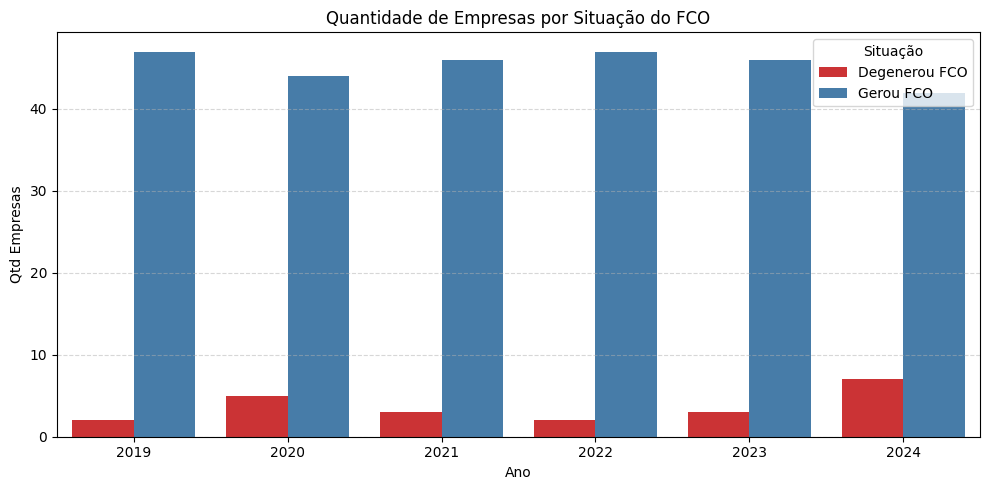

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertendo o resumo para formato "long" para usar no seaborn
df_plot = resumo_fco.reset_index().melt(id_vars='Year', var_name='Situação', value_name='Quantidade')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot, x='Year', y='Quantidade', hue='Situação', palette='Set1')

plt.title('Quantidade de Empresas por Situação do FCO')
plt.xlabel('Ano')
plt.ylabel('Qtd Empresas')
plt.legend(title='Situação')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Fluxo de Caixa Operacional das Top 50

In [46]:
lucro_e_fco = df_top_50.merge(df_fco, on=['Ticker'], how='left')

lucro_e_fco = lucro_e_fco.groupby(['Ticker', 'Year'], as_index=False)['Operating Cash Flow'].sum()

resumo_lucro_e_fco = lucro_e_fco.pivot_table(
    index = 'Ticker',
    columns = 'Year',
    values = 'Operating Cash Flow',
    aggfunc = 'sum'
)

# Adiciona coluna com total
resumo_lucro_e_fco['Total'] = resumo_lucro_e_fco.sum(axis=1)

# Classifica em ordem decrescente
resumo_lucro_e_fco = resumo_lucro_e_fco.sort_values(by='Total', ascending=False)

resumo_lucro_e_fco = resumo_lucro_e_fco.map(lambda x: f"{x:,.2f}")

resumo_lucro_e_fco

Year,2019,2020,2021,2022,2023,2024,Total
Ticker,,,,,,,
PKX,"4,614,163.00","8,685,737.00","6,259,365.00","6,186,765.00","6,167,695.00","285,142.00","32,198,867.00"
TM,"2,004,496.00","2,228,089.00","3,534,581.00","2,907,030.00","3,915,294.00","1,420,232.00","16,009,722.00"
HMC,"605,399.00","1,200,208.00","1,193,991.00","2,444,574.00","837,985.00","325,559.00","6,607,716.00"
TSM,"462,468.00","822,666.00","1,112,160.00","1,610,599.00","1,241,967.00","436,311.00","5,686,171.00"
SONY,"834,067.00","1,475,043.00","989,453.00","343,419.00","1,328,272.00","441,255.00","5,411,509.00"
IX,"720,689.00","1,081,472.00","1,108,248.00","917,465.00","1,260,050.00","316,816.00","5,404,740.00"
BBAR,"80,895.29","-29,813.76","218,418.00","113,020.58","601,230.00",0.00,"983,750.11"
BABA,"178,443.00","209,767.00","173,982.00","161,311.00","190,654.00","23,340.00","937,497.00"
AAPL,"62,062.00","88,921.00","112,241.00","109,190.00","116,433.00","22,690.00","511,537.00"


### Overview Fluxo de Caixa Investimento

In [47]:
# Soma da coluna de Investing Cash Flow por ano e empresa
df_fci = df_filtrado_2.groupby(['Year', 'Ticker'], as_index=False)['Investing Cash Flow'].sum()

# Criação de uma coluna de geração de caixa investimento
df_fci['Situação'] = df_fci['Investing Cash Flow'].apply(lambda x: 'Gerou FCI' if x > 0 else 'Degenerou FCI')

# Resumo numa tabela dinâmica da quantidade de empresas que geraram ou não FCI
resumo_fci = df_fci.groupby(['Year', 'Situação']).size().unstack(fill_value=0)

print('Overview do Fluxo de Caixa Investimento das Empresas\n')
resumo_fci

Overview do Fluxo de Caixa Investimento das Empresas



Situação,Degenerou FCI,Gerou FCI
Year,,
2019,39,10
2020,44,5
2021,46,3
2022,46,3
2023,44,5
2024,38,11


### Representação gráfica das situações de FCI

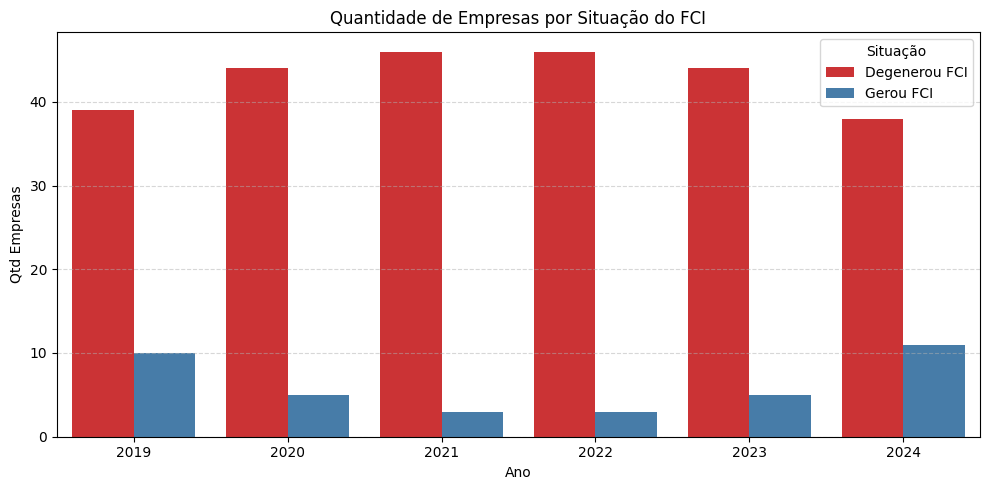

In [63]:
df_plot2 = resumo_fci.reset_index().melt(id_vars='Year', var_name='Situação', value_name='Quantidade')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot2, x='Year', y='Quantidade', hue='Situação', palette='Set1')

plt.title('Quantidade de Empresas por Situação do FCI')
plt.xlabel('Ano')
plt.ylabel('Qtd Empresas')
plt.legend(title='Situação')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Fluxo de Caixa Investimento das Top 50

In [53]:
lucro_e_fci = df_top_50.merge(df_fci, on=['Ticker'], how='left')

lucro_e_fci = lucro_e_fci.groupby(['Ticker', 'Year'], as_index=False)['Investing Cash Flow'].sum()

resumo_lucro_e_fci = lucro_e_fci.pivot_table(
    index = 'Ticker',
    columns = 'Year',
    values = 'Investing Cash Flow',
    aggfunc = 'sum'
)

# Adiciona coluna com total
resumo_lucro_e_fci['Total'] = resumo_lucro_e_fci.sum(axis=1)

# Classifica em ordem decrescente
resumo_lucro_e_fci = resumo_lucro_e_fci.sort_values(by='Total', ascending=False)

resumo_lucro_e_fci = resumo_lucro_e_fci.map(lambda x: f"{x:,.2f}")

resumo_lucro_e_fci

Year,2019,2020,2021,2022,2023,2024,Total
Ticker,,,,,,,
WFC,"-20,605.00","122,554.00","-7,619.00","-42,476.00","16,043.00","21,095.00","88,992.00"
NVS,"-3,554.00","-13,182.00","4,208.00","1,468.00","5,596.00",-899.00,"-6,363.00"
KO,483.00,"-1,477.00","-2,765.00",-763.00,"-3,349.00",330.00,"-7,541.00"
V,367.00,"1,504.00","-1,338.00","-4,251.00","-3,385.00","-1,176.00","-8,279.00"
AAPL,"13,036.00",795.00,"-22,067.00","-7,693.00","7,077.00",-310.00,"-9,162.00"
PG,"5,076.00","-2,762.00","-3,422.00","-3,780.00","-4,402.00",-762.00,"-10,052.00"
GSK,"-1,402.00","2,161.00","-1,777.00","-8,772.00","-1,595.00",-149.00,"-11,534.00"
MA,"-1,853.00","-1,879.00","-5,272.00","-1,470.00","-1,351.00",-174.00,"-11,999.00"
QCOM,-748.00,"-6,262.00","-2,266.00","-5,825.00",-361.00,-939.00,"-16,401.00"


### Overview Fluxo de Caixa Financiamento

In [54]:
# Soma da coluna de Financing Cash Flow por ano e empresa
df_fcf = df_filtrado_2.groupby(['Year', 'Ticker'], as_index=False)['Financing Cash Flow'].sum()

# Cria uma coluna de geração de caixa financiamento
df_fcf['Situação'] = df_fcf['Financing Cash Flow'].apply(lambda x: 'Gerou FCF' if x > 0 else 'Degenerou FCF')

# Resumo numa tabela dinâmica da quantidade de empresas que geraram ou não FCF
resumo_fcf = df_fcf.groupby(['Year', 'Situação']).size().unstack(fill_value=0)

print('Overview do Fluxo de Caixa Financiamento das Empresas\n')
resumo_fcf

Overview do Fluxo de Caixa Financiamento das Empresas



Situação,Degenerou FCF,Gerou FCF
Year,,
2019,39,10
2020,33,16
2021,39,10
2022,38,11
2023,37,12
2024,32,17


### Representação Gráfica das situações de FCF

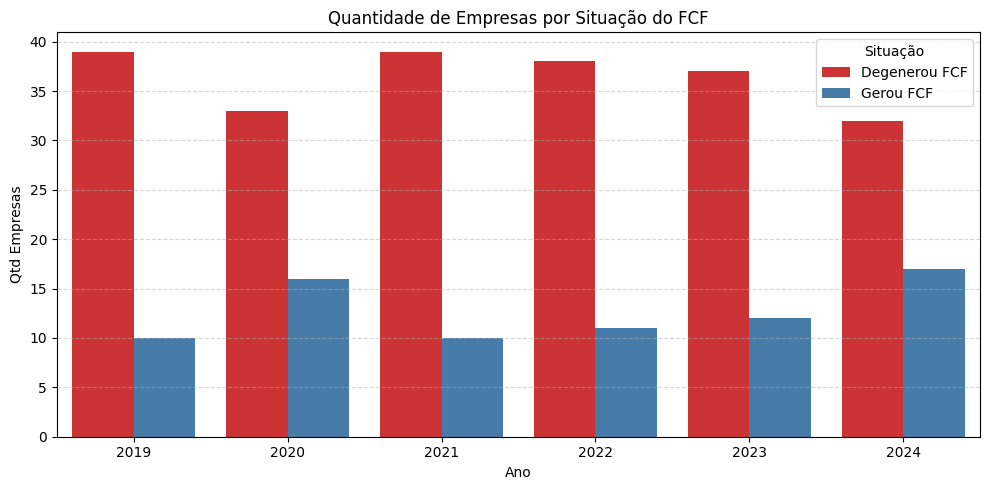

In [62]:
df_plot3 = resumo_fcf.reset_index().melt(id_vars='Year', var_name='Situação', value_name='Quantidade')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot3, x='Year', y='Quantidade', hue='Situação', palette='Set1')

plt.title('Quantidade de Empresas por Situação do FCF')
plt.xlabel('Ano')
plt.ylabel('Qtd Empresas')
plt.legend(title='Situação')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Fluxo de Caixa Financiamento das Top 50

In [56]:
lucro_e_fcf = df_top_50.merge(df_fcf, on=['Ticker'], how='left')

lucro_e_fcf = lucro_e_fcf.groupby(['Ticker', 'Year'], as_index=False)['Financing Cash Flow'].sum()

resumo_lucro_e_fcf = lucro_e_fcf.pivot_table(
    index = 'Ticker',
    columns = 'Year',
    values = 'Financing Cash Flow',
    aggfunc = 'sum'
)

# Adiciona coluna com total
resumo_lucro_e_fcf['Total'] = resumo_lucro_e_fcf.sum(axis=1)

# Classifica em ordem decrescente
resumo_lucro_e_fcf = resumo_lucro_e_fcf.sort_values(by='Total', ascending=False)

resumo_lucro_e_fcf = resumo_lucro_e_fcf.map(lambda x: f"{x:,.2f}")

resumo_lucro_e_fcf

Year,2019,2020,2021,2022,2023,2024,Total
Ticker,,,,,,,
TM,"-5,710.00","2,564,581.00","-1,709,110.00","-711,479.00","2,075,462.00","863,097.00","3,076,841.00"
JPM,"-36,448.00","596,645.00","275,993.00","-126,257.00","-25,571.00","141,168.00","825,530.00"
BAC,"18,885.00","355,819.00","291,650.00","-106,039.00","93,345.00","68,658.00","722,318.00"
C,"3,396.00","233,595.00","17,272.00","137,763.00",687.00,"12,351.00","405,064.00"
IX,"108,506.00","270,290.00","-98,413.00","-189,147.00","316,440.00","-32,876.00","374,800.00"
GS,-477.00,"70,380.00","134,738.00","59,602.00","27,800.00","7,171.00","299,214.00"
MS,"3,898.00","83,784.00","41,547.00","22,714.00","-2,726.00","8,857.00","158,074.00"
AXP,-436.00,"-9,068.00","-14,933.00","24,509.00","18,379.00","5,181.00","23,632.00"
GM,"-5,754.00","5,552.00","1,744.00",383.00,"-6,353.00",300.00,"-4,128.00"


### Overview Fluxo de Caixa Líquido

A coluna de Fluxo de Caixa Líquido não estava correta, para tal foi necessário criar um novo df para somar os FCs Operacional, Financiamento e Investimento

In [57]:
# Criação um DF com o FC Operacional, Financiamento e Investimento

df_fcl1 = [lucro_e_fci, lucro_e_fcf]

df_fcl2 = lucro_e_fco.copy()

for df in df_fcl1:
  df_fcl2 =  df_fcl2.merge(df, on=['Year', 'Ticker'], how='left')

df_fcl2['Net Cash Flow'] = df_fcl2['Operating Cash Flow'] + df_fcl2['Investing Cash Flow'] + df_fcl2['Financing Cash Flow']

df_fcl2

,Ticker,Year,Operating Cash Flow,Investing Cash Flow,Financing Cash Flow,Net Cash Flow
0,AAPL,2019,62062.0,13036.0,-73250.0,1848.0
1,AAPL,2020,88921.0,795.0,-93662.0,-3946.0
2,AAPL,2021,112241.0,-22067.0,-89263.0,911.0
3,AAPL,2022,109190.0,-7693.0,-118153.0,-16656.0
4,AAPL,2023,116433.0,7077.0,-103510.0,20000.0
...,...,...,...,...,...,...
289,WMT,2020,33596.0,-9350.0,-18426.0,5820.0
290,WMT,2021,29485.0,-5094.0,-22890.0,1501.0
291,WMT,2022,23588.0,-17450.0,-10296.0,-4158.0
292,WMT,2023,32157.0,-20131.0,-11637.0,389.0


In [58]:
# Criação uma coluna de geração de caixa Global
df_fcl2['Situação'] = df_fcl2['Net Cash Flow'].apply(lambda x: 'Gerou FCL' if x > 0 else 'Degenerou FCL')

# Resumo numa tabela dinâmica da quantidade de empresas que geraram ou não FCF
resumo_fcl = df_fcl2.groupby(['Year', 'Situação']).size().unstack(fill_value=0)

print('Overview do Fluxo de Caixa Líquido das Empresas\n')

resumo_fcl

Overview do Fluxo de Caixa Líquido das Empresas



Situação,Degenerou FCL,Gerou FCL
Year,,
2019,19,30
2020,12,37
2021,25,24
2022,29,20
2023,18,31
2024,23,26


### Representação gráfica das situações de Fluxo de Caixa Líquido

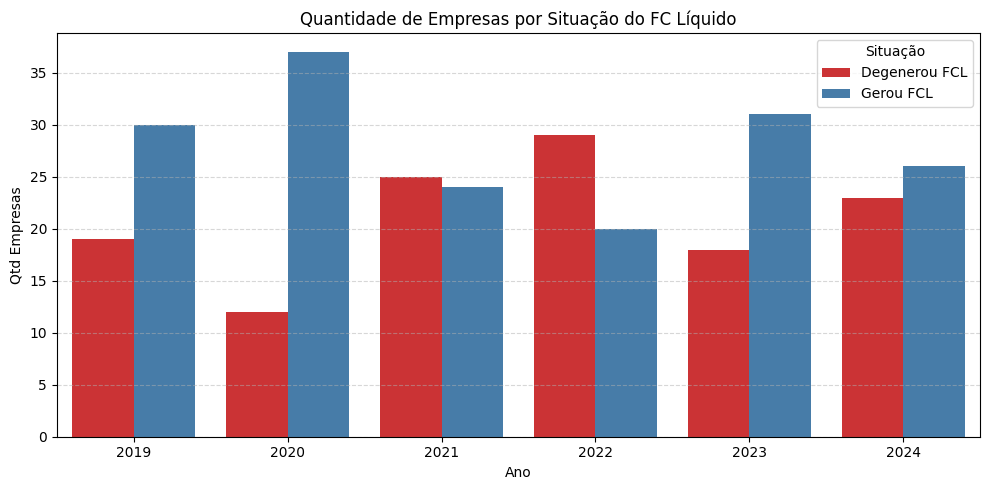

In [65]:
df_plot4 = resumo_fcl.reset_index().melt(id_vars='Year', var_name='Situação', value_name='Quantidade')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot4, x='Year', y='Quantidade', hue='Situação', palette='Set1')

plt.title('Quantidade de Empresas por Situação do FC Líquido')
plt.xlabel('Ano')
plt.ylabel('Qtd Empresas')
plt.legend(title='Situação')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Fluxo de Caixa Líquido das Top 50

In [ ]:
lucro_e_fcl = df_top_50.merge(df_fcl2, on=['Ticker'], how='left')

lucro_e_fcl = lucro_e_fcl.groupby(['Ticker', 'Year'], as_index=False)['Net Cash Flow'].sum()

resumo_lucro_e_fcl = lucro_e_fcl.pivot_table(
    index = 'Ticker',
    columns = 'Year',
    values = 'Net Cash Flow',
    aggfunc = 'sum'
)

# Adiciona coluna com total
resumo_lucro_e_fcl['Total'] = resumo_lucro_e_fcl.sum(axis=1)

# Classifica em ordem decrescente
resumo_lucro_e_fcl = resumo_lucro_e_fcl.sort_values(by='Total', ascending=False)

resumo_lucro_e_fcl = resumo_lucro_e_fcl.map(lambda x: f"{x:,.2f}")

resumo_lucro_e_fcl

Year,2019,2020,2021,2022,2023,2024,Total
Ticker,,,,,,,
TM,"273,430.00","704,297.00","1,004,615.00","-69,778.00","1,675,330.00","1,514,707.00","5,102,601.00"
PKX,"841,850.00","1,335,604.00","-92,808.00","3,286,302.00","-1,399,122.00","138,833.00","4,110,659.00"
HMC,"-30,716.00","547,266.00","-378,622.00","623,214.00","556,323.00","415,684.00","1,733,149.00"
TSM,"-179,370.68","228,269.08","412,402.48","219,426.24","130,952.19","204,818.39","1,016,497.70"
BBAR,"69,056.23","-67,560.82","202,356.68","77,359.38","531,777.08",0.00,"812,988.55"
JPM,"-39,836.00","254,823.00","224,733.00","-156,957.00","55,046.00","-56,369.00","281,440.00"
SONY,"-46,919.00","504,058.00","-149,558.00","-678,195.00","700,323.00","-170,580.00","159,129.00"
BAC,"-10,302.00","216,147.00","-28,834.00","-114,895.00","102,940.00","-18,203.00","146,853.00"
GS,"45,662.00","17,489.00","110,571.00","-7,650.00","-2,099.00","-28,847.00","135,126.00"


# Consolidação

Mesclagem dos DFs top 50 e Fluxo de Caixa (Operacional, Investimento e Fianciamento)



In [ ]:
consolidado = top_50_tabular.merge(lucro_e_fco, on=['Ticker', 'Year'], how='left')
consolidado = consolidado.merge(lucro_e_fci, on=['Ticker', 'Year'], how='left')
consolidado = consolidado.merge(lucro_e_fcf, on=['Ticker', 'Year'], how='left')
consolidado = consolidado.merge(lucro_e_fcl, on=['Ticker', 'Year'], how='left')

# Filtro de Caixa Operacional maior que zero
consolidado = consolidado[consolidado['Operating Cash Flow'] != 0]

# Verifica se a empresa converte lucro em caixa operacional
consolidado.loc[:, 'Conversão de Lucro'] = consolidado['Operating Cash Flow'] / consolidado['Net Income']

consolidado = consolidado[consolidado['Conversão de Lucro'] > 0]

consolidado

,Ticker,Year,Net Income,Operating Cash Flow,Investing Cash Flow,Financing Cash Flow,Net Cash Flow,Conversão de Lucro
0,PKX,2019,1123152.0,4614163.0,-2938773.00,-833540.00,841850.00,4.108227
1,TM,2019,1708838.0,2004496.0,-1725356.00,-5710.00,273430.00,1.173017
2,SONY,2019,569547.0,834067.0,-1026082.00,145096.00,-46919.00,1.464439
3,HMC,2019,485288.0,605399.0,-435985.00,-200130.00,-30716.00,1.247505
4,TSM,2019,292554.0,462468.0,-394613.13,-247225.55,-179370.68,1.580795
...,...,...,...,...,...,...,...,...
289,UPS,2024,1113.0,3316.0,1566.00,-3666.00,1216.00,2.979335
290,BMO,2024,3152.0,22297.0,-10819.00,-9308.00,2170.00,7.073921
291,GSK,2024,1046.0,958.0,-149.00,-1060.00,-251.00,0.915870
292,AXP,2024,2437.0,5552.0,-3144.00,5181.00,7589.00,2.278211


## Listagem das empresas que converteram lucro em caixa operacional todos os anos

In [ ]:
# Coluna booleana de validação
consolidado['Converteu'] = consolidado['Conversão de Lucro'] > 0

# Lista de anos
anos_disponiveis = consolidado['Year'].unique()

# Criação de um conjunto para cada ano com as empresas que converteram lucro
sets_por_ano = [
    set(consolidado[(consolidado['Year'] == ano) & (consolidado['Converteu'])]['Ticker'])
    for ano in anos_disponiveis
]

# Interseção entre todos os conjuntos
empresas_que_converteram_todos_os_anos = set.intersection(*sets_por_ano)

# Lista das empresas
empresas_que_converteram_todos_os_anos = list(empresas_que_converteram_todos_os_anos)

df_empresas_que_converteram_todos_os_anos = pd.DataFrame(empresas_que_converteram_todos_os_anos, columns=['Ticker'])

print(f"Existem {len(empresas_que_converteram_todos_os_anos)} empresas que converteram lucro em caixa operacional em todos os anos {anos_disponiveis}.")

df_empresas_que_converteram_todos_os_anos

Existem 40 empresas que converteram lucro em caixa operacional em todos os anos [2019 2020 2021 2022 2023 2024].


,Ticker
0,PFE
1,BMO
2,IX
3,META
4,AAPL
5,CSCO
6,TSM
7,GM
8,CVS
9,SONY


## Decrição das conversões

In [ ]:
consolidado2 = df_empresas_que_converteram_todos_os_anos.merge(consolidado, on=['Ticker'], how='left')


consolidado2['Conversão de Lucro'].describe()


,Conversão de Lucro
count,240.000000
mean,2.003599
std,2.583455
min,0.112197
25%,1.172234
50%,1.467662
75%,2.028378
max,35.632877


## Variação ano a ano - De 2019 a 2024

In [ ]:
# Calculando a variação percentual ano a ano por empresa
consolidado2['Var Ano a Ano'] = consolidado2.groupby('Ticker')['Conversão de Lucro'].pct_change()

# Exibindo a variação ano a ano por Ticker
variacao_ano_a_ano = consolidado2[['Ticker', 'Year', 'Net Income', 'Var Ano a Ano']].dropna()

variacao_ano_a_ano.pivot_table(
    index = 'Ticker',
    columns = 'Year',
    values = 'Var Ano a Ano',
    aggfunc = 'sum'
)

Year,2020,2021,2022,2023,2024
Ticker,,,,,
AAPL,0.030174,-0.197494,0.027852,0.005659,-0.167984
ABBV,1.005849,-0.482077,0.067894,1.228584,-0.371645
AVGO,0.417541,-0.527884,-0.302601,-0.138785,1.122889
AXP,0.826902,0.018832,0.543919,-0.209971,0.027951
BABA,0.080521,0.812864,1.058646,-0.612853,2.743266
BMO,-0.002085,-0.430422,-0.935541,5.071378,2.181826
CHT,-0.074658,-0.056659,0.007247,-0.047027,-0.254278
CMCSA,0.208613,-0.123418,1.389445,-0.623440,0.098579
CSCO,0.038214,-0.148287,-0.077756,0.125963,-0.215130


## Variação positiva de 2024 em relação a 2023 - Empresas com seus setores

In [ ]:
variacao_ano_a_ano = variacao_ano_a_ano[variacao_ano_a_ano['Year'] == 2024]

variacao_ano_a_ano = variacao_ano_a_ano[variacao_ano_a_ano['Var Ano a Ano'] > 0]

variacao_ano_a_ano = variacao_ano_a_ano.sort_values(by='Var Ano a Ano', ascending=False)

versao1 = variacao_ano_a_ano.merge(empresas_e_setores, on=['Ticker'], how='left')

versao1

,Ticker,Year,Net Income,Var Ano a Ano,Sector
0,BABA,2024,3270.0,2.743266,Consumer Cyclical
1,BMO,2024,3152.0,2.181826,Financial Services
2,CVS,2024,1113.0,1.737754,Healthcare
3,AVGO,2024,3446.0,1.122889,Technology
4,UPS,2024,1113.0,0.952079,Industrials
5,JNJ,2024,3255.0,0.732898,Healthcare
6,TM,2024,997691.0,0.635936,Consumer Cyclical
7,SONY,2024,189005.0,0.621507,Technology
8,HMC,2024,237565.0,0.533724,Consumer Cyclical
9,TSM,2024,225485.0,0.327014,Technology


## Resumo de Fluxo de Caixa das empresas que tiveram variação positiva

In [ ]:
operacao = versao1.merge(lucro_e_fco, on=['Ticker', 'Year'], how='left')

investimento = operacao.merge(lucro_e_fci, on=['Ticker', 'Year'], how='left')

financiamento = investimento.merge(lucro_e_fcf, on=['Ticker', 'Year'], how='left')

caixa_liquido = financiamento.merge(lucro_e_fcl, on=['Ticker', 'Year'], how='left')

caixa_liquido = caixa_liquido[['Ticker', 'Year', 'Sector', 'Var Ano a Ano', 'Net Income', 'Operating Cash Flow', 'Investing Cash Flow', 'Financing Cash Flow', 'Net Cash Flow']]


## Comportamento do Fluxo de Caixa Financiamento das empresas selecionadas

In [ ]:
fcf_comportamento = caixa_liquido[['Ticker' , 'Year', 'Financing Cash Flow']]

df_filtrado_fcf = df_filtrado[['Ticker', 'Year', 'Dividends Paid', 'Share Issuance / Repurchase', 'Debt Issued / Paid', 'Other Financing Activities']]

df_filtrado_fcf = df_filtrado_fcf.groupby(['Ticker', 'Year'], as_index=False).sum()

# Merge do comportamento com o df filtrado para verificar a composição da situação financeira

fcf_comportamento = fcf_comportamento.merge(df_filtrado_fcf, on=['Ticker', 'Year'], how='left')

fcf_comportamento

,Ticker,Year,Financing Cash Flow,Dividends Paid,Share Issuance / Repurchase,Debt Issued / Paid,Other Financing Activities
0,BABA,2024,-54012.00,0.00,0.00,0.0,-54012.00
1,BMO,2024,-9308.00,-1414.00,39.00,-2512.0,-5421.00
2,CVS,2024,-1227.00,-840.00,-2824.00,2501.0,-64.00
3,AVGO,2024,12408.00,-4878.00,-9774.00,27076.0,-16.00
4,UPS,2024,-3666.00,-1348.00,54.00,-2198.0,-174.00
5,JNJ,2024,546.00,-2869.00,-1280.00,4602.0,93.00
6,TM,2024,863097.00,0.00,-39485.00,922765.0,-20183.00
7,SONY,2024,-412902.00,-196.00,-128269.00,-287845.0,3408.00
8,HMC,2024,415971.00,0.00,-37434.00,-760451.0,1213856.00
9,TSM,2024,-71685.62,-77796.21,0.00,1370.0,4741.00


## Filtrando somente empresas que pagaram dividendos em 2024

In [ ]:
paga_dividendos = fcf_comportamento[fcf_comportamento['Dividends Paid'] < 0]

paga_dividendos

,Ticker,Year,Financing Cash Flow,Dividends Paid,Share Issuance / Repurchase,Debt Issued / Paid,Other Financing Activities
1,BMO,2024,-9308.00,-1414.00,39.00,-2512.0,-5421.00
2,CVS,2024,-1227.00,-840.00,-2824.00,2501.0,-64.00
3,AVGO,2024,12408.00,-4878.00,-9774.00,27076.0,-16.00
4,UPS,2024,-3666.00,-1348.00,54.00,-2198.0,-174.00
5,JNJ,2024,546.00,-2869.00,-1280.00,4602.0,93.00
7,SONY,2024,-412902.00,-196.00,-128269.00,-287845.0,3408.00
9,TSM,2024,-71685.62,-77796.21,0.00,1370.0,4741.00
10,ORCL,2024,-4737.00,-2201.00,-593.00,-1916.0,-27.00
11,HD,2024,-5666.00,-4308.00,-1942.00,760.0,-176.00
12,MSFT,2024,-18808.00,-5572.00,-3691.00,-9047.0,-498.00


## Remoção dos Outliers de Dívida paga ou emitida

Empresas com muitas dívidas indica necessidade excessiva de capital de terceiros ou alto compromentimento com amortização e despesas financeiras (juros)

In [ ]:
coluna = 'Debt Issued / Paid'

Q1 = paga_dividendos[coluna].quantile(0.25)
Q3 = paga_dividendos[coluna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra os dados removendo os outliers
divida_controlada = paga_dividendos[(paga_dividendos[coluna] >= limite_inferior) & (paga_dividendos[coluna] <= limite_superior)]

divida_controlada.sort_values(by = 'Debt Issued / Paid', ascending = True)

,Ticker,Year,Financing Cash Flow,Dividends Paid,Share Issuance / Repurchase,Debt Issued / Paid,Other Financing Activities
17,WMT,2024,-13556.00,-3205.00,-2556.00,-6064.0,-1731.00
1,BMO,2024,-9308.00,-1414.00,39.00,-2512.0,-5421.00
4,UPS,2024,-3666.00,-1348.00,54.00,-2198.0,-174.00
10,ORCL,2024,-4737.00,-2201.00,-593.00,-1916.0,-27.00
13,CMCSA,2024,-4023.00,-1193.00,-2664.00,-263.0,97.00
14,QCOM,2024,-1580.00,-895.00,-536.00,0.0,-149.00
11,HD,2024,-5666.00,-4308.00,-1942.00,760.0,-176.00
9,TSM,2024,-71685.62,-77796.21,0.00,1370.0,4741.00
16,AXP,2024,5181.00,-452.00,-1263.00,1613.0,5283.00
2,CVS,2024,-1227.00,-840.00,-2824.00,2501.0,-64.00


## DataFrame Final da Análise de Lucro e DFC

In [ ]:
fcf_final = divida_controlada[['Ticker']]

df_final = fcf_final.merge(caixa_liquido, on=['Ticker'], how='left')

# Remoção de empresas com Fluxo de Caixa Líquido Negativo
df_final = df_final[df_final['Net Cash Flow'] > 0]

df_final = df_final.rename(columns={
    'Var Ano a Ano': 'Var 2023/2024'
})

df_final.to_excel('df_final.xlsx', index=False)

df_final

,Ticker,Year,Sector,Var 2023/2024,Net Income,Operating Cash Flow,Investing Cash Flow,Financing Cash Flow,Net Cash Flow
0,BMO,2024,Financial Services,2.181826,3152.0,22297.0,-10819.00,-9308.00,2170.00
1,CVS,2024,Healthcare,1.737754,1113.0,4903.0,-2094.00,-1227.00,1582.00
2,UPS,2024,Industrials,0.952079,1113.0,3316.0,1566.00,-3666.00,1216.00
3,JNJ,2024,Healthcare,0.732898,3255.0,3657.0,-464.00,546.00,3739.00
4,TSM,2024,Technology,0.327014,225485.0,436311.0,-159806.99,-71685.62,204818.39
5,ORCL,2024,Technology,0.239979,5545.0,11556.0,-4549.00,-4737.00,2270.00
6,HD,2024,Consumer Cyclical,0.193265,6401.0,10230.0,-2411.00,-5666.00,2153.00
7,CMCSA,2024,Communication Services,0.098579,3857.0,7848.0,-3511.00,-4023.00,314.00
8,QCOM,2024,Technology,0.063657,2326.0,3554.0,-939.00,-1580.00,1035.00
9,NTES,2024,Technology,0.042346,7634.0,9557.0,12860.00,-495.06,21921.94


## Lista final das empresas selecionadas

In [ ]:
lista_final_empresas = df_final['Ticker'].to_list()

print(f'Ao todo existem {len(lista_final_empresas)} empresas que tiveram variação positiva de FCO, pagaram divididendos em 2024 e não possuem um descasamento financeiro \n')

lista_final_empresas

Ao todo existem 11 empresas que tiveram variação positiva de FCO, pagaram divididendos em 2024 e não possuem um descasamento financeiro 



['BMO',
 'CVS',
 'UPS',
 'JNJ',
 'TSM',
 'ORCL',
 'HD',
 'CMCSA',
 'QCOM',
 'NTES',
 'AXP']

## Formatando a última data de publicação das demonstrações para dar match com a API da Marketstack

In [ ]:
from datetime import datetime, timedelta

# Converte para datetime
data_obj = datetime.strptime(ultima_data, "%d-%m-%Y")

# Formata para o novo formato ano-mês-dia
data_formatada = data_obj.strftime("%Y-%m-%d")

print(data_formatada)

2024-06-30


## Data da última demonstração + 7 dias

In [ ]:
data_mais_7 = data_obj + timedelta(days=7)

data_mais_7 = data_mais_7.strftime("%Y-%m-%d")

print(data_mais_7)

2024-07-07


In [ ]:
!pip install python-dotenv

In [ ]:
import os
from dotenv import load_dotenv, find_dotenv

# Carregando e encontrando o token da API
_ = load_dotenv(find_dotenv())

# Variável com o meu token
API_KEY = os.environ['my_key']

## Requisição na API

Conectando na API Marketstack para coletar dados de cotação a partir da última data de divulgação das demonstrações financeiras até 7 dias depois

Com a lista final das empresas, é feito um "Procv" no endpoint da URL

In [ ]:
import requests

todos_os_dados = []

# Filtro de chaves específicas do retorno JSON da API
chaves_json = ['open', 'close', 'name', 'symbol', 'exchange_code', 'date']

# Loop pelas empresas da lista final
for empresa in lista_final_empresas:

    url = f'https://api.marketstack.com/v2/eod?access_key={API_KEY}&symbols={empresa}&date_from={data_formatada}&date_to={data_mais_7}'

    response = requests.get(url)

    # Se o status for igual 200 a API tá pronta pra uso
    if response.status_code == 200:

        # Retorna os dados a partir da chave data
        dados = response.json().get('data', [])

        # Faz o GET nos dados das chaves específicas
        dados_filtrados = [
            {
                'open': item.get('open'), # Preço da ação na abertura
                'close': item.get('close'), # Preço da ação no fechamento
                'name': item.get('name'), # Nome do Ticker (empresa)
                'symbol': item.get('symbol'), # O Ticker
                'exchange_code': item.get('exchange_code'), # Nome da bolsa de valores onde o ativo é vendido
                'date': item.get('date') # Data dos dados da ação
            }

            # Itera sobre cada item da lista
            for item in dados
        ]

        # "Extende" os dados para fora das chaves
        todos_os_dados.extend(dados_filtrados)

    else:

        # Se a API não estiver pronta para uso, o status code vai indicar o porque
        print(f"Erro ao buscar dados de {empresa}: {response.status_code}")

# Dataframe com os dados "extendidos"
df_api = pd.DataFrame(todos_os_dados)

## DF filtrado do retorno da API

In [ ]:
ordem_colunas_api = ['symbol', 'name', 'exchange_code', 'date', 'open', 'close']

df_api = df_api[ordem_colunas_api]

df_api

,symbol,name,exchange_code,date,open,close
0,BMO,None,None,2024-07-05T00:00:00+0000,85.330,83.72
1,BMO,None,None,2024-07-03T00:00:00+0000,84.760,84.97
2,BMO,None,None,2024-07-02T00:00:00+0000,83.190,84.30
3,BMO,None,None,2024-07-01T00:00:00+0000,84.075,83.17
4,CVS,None,None,2024-07-05T00:00:00+0000,56.670,56.62
5,CVS,None,None,2024-07-03T00:00:00+0000,57.560,56.70
6,CVS,None,None,2024-07-02T00:00:00+0000,58.040,57.52
7,CVS,None,None,2024-07-01T00:00:00+0000,59.200,58.15
8,UPS,None,None,2024-07-05T00:00:00+0000,134.870,136.35
9,UPS,None,None,2024-07-03T00:00:00+0000,135.740,135.55


## Adicionando dados extras sobre as empresas

In [ ]:
# Infos adicionais das empresas
infos_extras_empresas = []

# Loop pelas empresas
for empresa in lista_final_empresas:
    url_adicional = f'http://api.marketstack.com/v2/tickers/{empresa}?access_key={API_KEY}'
    response_adicional = requests.get(url_adicional)

    if response_adicional.status_code == 200:
        dados_extras = response_adicional.json()
        infos_extras_empresas.append(dados_extras)
    else:
        print(f"Erro ao buscar dados de {empresa}: {response_adicional.status_code}")

# Criação de um DataFrame com todos os dados
df_empresas_infos = pd.DataFrame(infos_extras_empresas)

## DF do retorno da API extra

In [ ]:
df_extra_infos_empresas = pd.json_normalize(infos_extras_empresas)

colunas_df_extra = ['symbol', 'name', 'item_type', 'sector', 'industry', 'sic_name', 'stock_exchange.name', 'stock_exchange.acronym']

df_extra_infos_empresas = df_extra_infos_empresas[colunas_df_extra]

df_extra_infos_empresas

,symbol,name,item_type,sector,industry,sic_name,stock_exchange.name,stock_exchange.acronym
0,BMO,Bank of Montreal,equity,Financial Services,,"Commercial Banks, NEC","NEW YORK STOCK EXCHANGE, INC.",NYSE
1,CVS,CVS HEALTH Corp,equity,Healthcare,Healthcare Plans,Retail-Drug Stores and Proprietary Stores,"NEW YORK STOCK EXCHANGE, INC.",NYSE
2,UPS,UNITED PARCEL SERVICE INC,equity,Industrials,Integrated Freight & Logistics,Trucking & Courier Services (No Air),"NEW YORK STOCK EXCHANGE, INC.",NYSE
3,JNJ,Johnson &amp; Johnson,equity,Healthcare,Drug Manufacturers—General,Pharmaceutical Preparations,"NEW YORK STOCK EXCHANGE, INC.",NYSE
4,TSM,Taiwan Semiconductor Manufacturing Company Lim...,equity,Technology,Semiconductors,Semiconductors & Related Devices,"NEW YORK STOCK EXCHANGE, INC.",NYSE
5,ORCL,ORACLE CORP,equity,Technology,Software—Infrastructure,Services-Prepackaged Software,"NEW YORK STOCK EXCHANGE, INC.",NYSE
6,HD,"The Home Depot, Inc.",equity,Consumer Cyclical,Home Improvement Retail,Retail-Lumber & Other Building Materials Dealers,"NEW YORK STOCK EXCHANGE, INC.",NYSE
7,CMCSA,COMCAST CORP,equity,Communication Services,Telecom Services,Cable & Other Pay Television Services,NASDAQ - ALL MARKETS,NASDAQ
8,QCOM,QUALCOMM INC/DE,equity,Technology,Semiconductors,Radio & Tv Broadcasting & Communications Equip...,NASDAQ - ALL MARKETS,NASDAQ
9,NTES,"NetEase, Inc.",equity,Communication Services,Electronic Gaming & Multimedia,Services-Prepackaged Software,NASDAQ - ALL MARKETS,NASDAQ


## DF final das APIs

In [ ]:
df_final_api = df_api.merge(df_extra_infos_empresas, on=['symbol'], how='left')

colunas_df_final = ['symbol', 'name_y', 'date', 'open', 'close', 'item_type', 'sector', 'industry', 'sic_name', 'stock_exchange.name', 'stock_exchange.acronym']

df_final_api = df_final_api[colunas_df_final]

df_final_api = df_final_api.rename(columns={'name_y': 'name'})

df_final_api['date'] = pd.to_datetime(df_final_api['date'])

df_final_api['date'] = df_final_api['date'].dt.strftime('%d-%m-%Y')

df_final_api.to_excel('df_final_api.xlsx', index=False)

df_final_api

,symbol,name,date,open,close,item_type,sector,industry,sic_name,stock_exchange.name,stock_exchange.acronym
0,BMO,Bank of Montreal,05-07-2024,85.330,83.72,equity,Financial Services,,"Commercial Banks, NEC","NEW YORK STOCK EXCHANGE, INC.",NYSE
1,BMO,Bank of Montreal,03-07-2024,84.760,84.97,equity,Financial Services,,"Commercial Banks, NEC","NEW YORK STOCK EXCHANGE, INC.",NYSE
2,BMO,Bank of Montreal,02-07-2024,83.190,84.30,equity,Financial Services,,"Commercial Banks, NEC","NEW YORK STOCK EXCHANGE, INC.",NYSE
3,BMO,Bank of Montreal,01-07-2024,84.075,83.17,equity,Financial Services,,"Commercial Banks, NEC","NEW YORK STOCK EXCHANGE, INC.",NYSE
4,CVS,CVS HEALTH Corp,05-07-2024,56.670,56.62,equity,Healthcare,Healthcare Plans,Retail-Drug Stores and Proprietary Stores,"NEW YORK STOCK EXCHANGE, INC.",NYSE
5,CVS,CVS HEALTH Corp,03-07-2024,57.560,56.70,equity,Healthcare,Healthcare Plans,Retail-Drug Stores and Proprietary Stores,"NEW YORK STOCK EXCHANGE, INC.",NYSE
6,CVS,CVS HEALTH Corp,02-07-2024,58.040,57.52,equity,Healthcare,Healthcare Plans,Retail-Drug Stores and Proprietary Stores,"NEW YORK STOCK EXCHANGE, INC.",NYSE
7,CVS,CVS HEALTH Corp,01-07-2024,59.200,58.15,equity,Healthcare,Healthcare Plans,Retail-Drug Stores and Proprietary Stores,"NEW YORK STOCK EXCHANGE, INC.",NYSE
8,UPS,UNITED PARCEL SERVICE INC,05-07-2024,134.870,136.35,equity,Industrials,Integrated Freight & Logistics,Trucking & Courier Services (No Air),"NEW YORK STOCK EXCHANGE, INC.",NYSE
9,UPS,UNITED PARCEL SERVICE INC,03-07-2024,135.740,135.55,equity,Industrials,Integrated Freight & Logistics,Trucking & Courier Services (No Air),"NEW YORK STOCK EXCHANGE, INC.",NYSE


### Gráfico com os preços de abertura e fechamento das ações de cada empresa por data

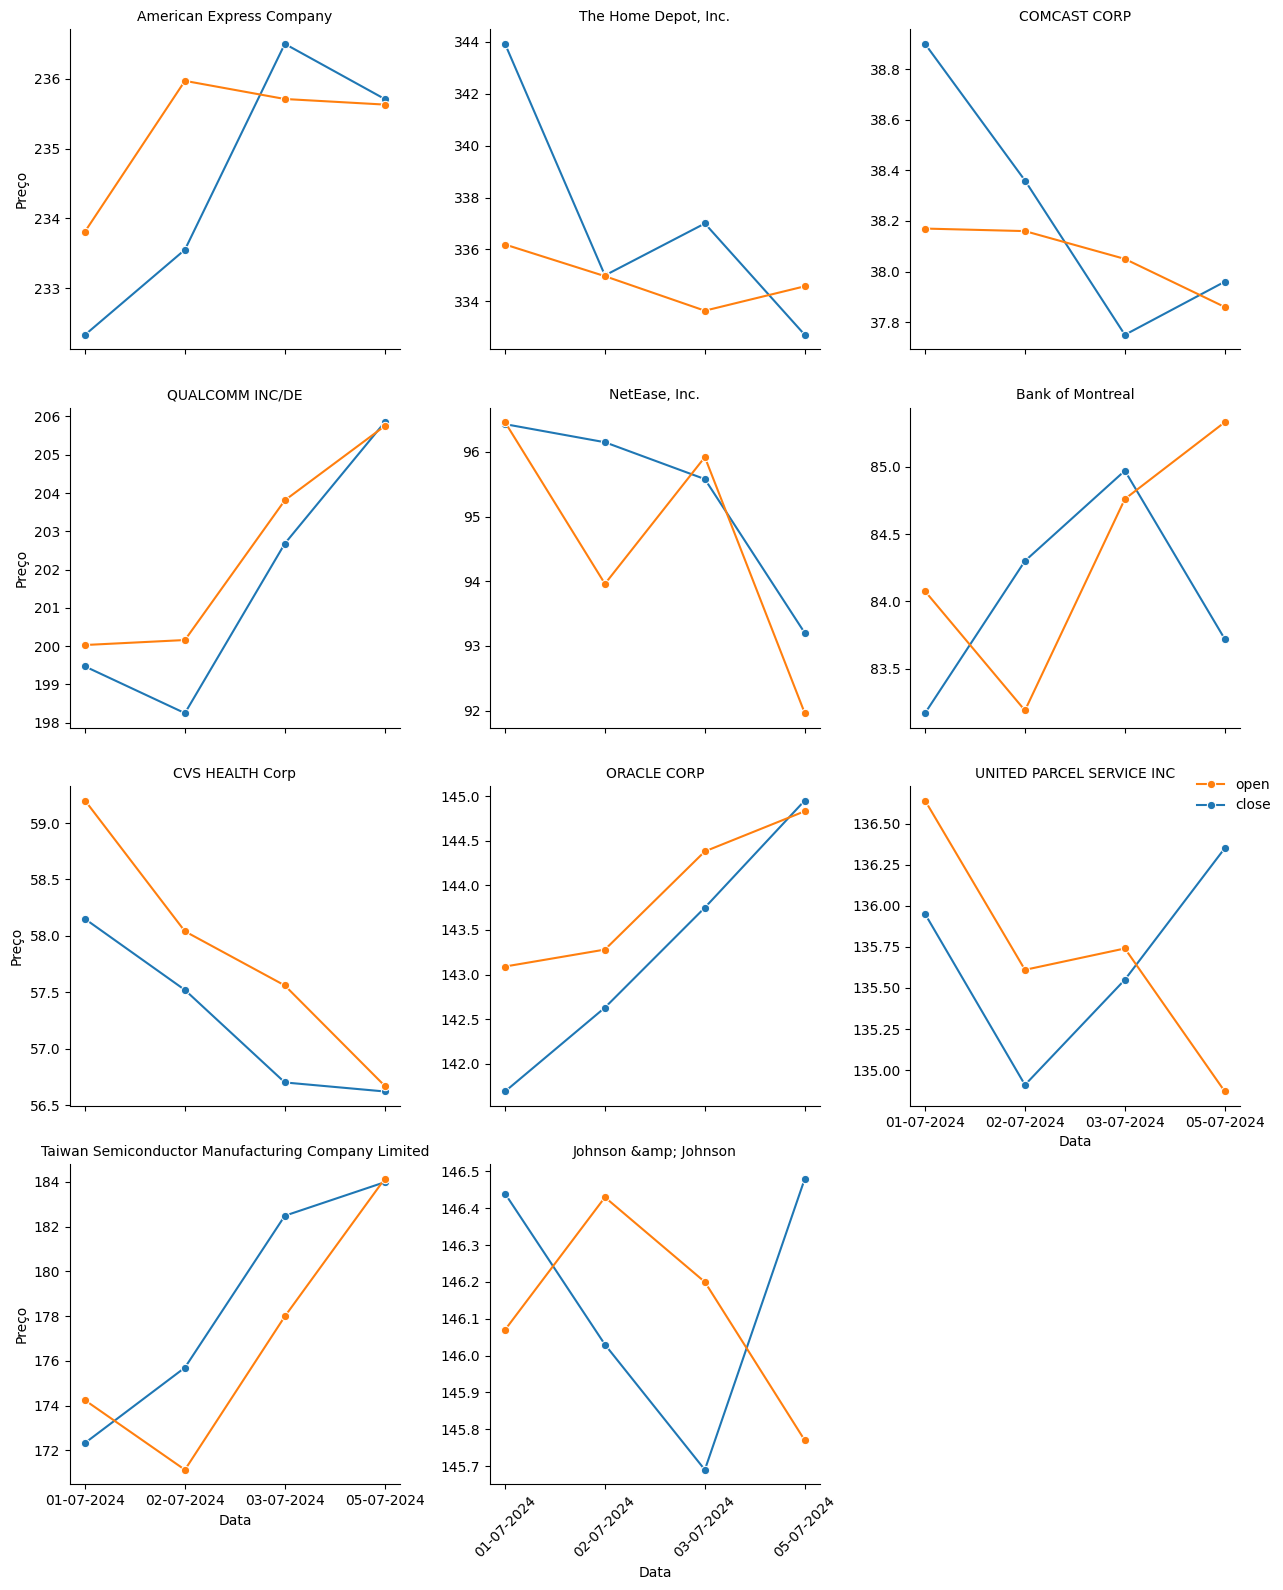

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transforma o DataFrame de formato largo para longo
df_long = df_final_api.melt(
    id_vars=['name', 'date'],
    value_vars=['open', 'close'],
    var_name='Tipo',
    value_name='Preço'
)

df_long = df_long.sort_values(by='date')

# Gráfico separado por empresa
g = sns.FacetGrid(df_long, col='name', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.lineplot, x='date', y='Preço', hue='Tipo', marker='o')

# Ajustes visuais
g.set_titles('{col_name}')
g.set_axis_labels('Data', 'Preço')
g.add_legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Conclusão:

1. Existem 3686 empresas no Dataset original.

2. Dessas, 1250 empresas registraram lucros em todos os anos (2019 a 2024).

3. Para fins de investigação, foram selecionadas as 50 empresas que mais lucraram entre 2019 e 2024

4. Em todos os anos, a maioria das empresas gerou caixa operacional e degenerou os caixas investimento e financiamento.

5. A geração de caixa global (caixa líquido) foi mais equilibrada, principalmente nos anos de 2021 e 2024.

6. 40 empresas converteram seus lucros em caixa operacional todos os anos.

	- Fórmula da conversão: Operating Cash Flow / Net income.
	- Critério da conversão: Conversão de Lucro > 0.

7. Analisando o ano de 2024 versus 2023, apenas 18 empresas variaram positivamente na conversão de lucros.

8. A partir do Fluxo de Caixa Financiamento, foram analisadas as condições Pagamento de Dividendos e Emissão ou pagamento de dívidas, onde observou-se o seguinte comportamento:

	- 15 empresas pagaram dividendos em 2024.
	- Dessas, 12 tinham um controle saudável da dependência de capital de terceiros.

9. A lista das 12 empresas ainda passou pelo critério de Fluxo de Caixa Líquido positivo, onde o número final caiu para 11 empresas.

10. O cruzamento das 11 empresas finais com suas respectivas informações da API da Marketstack, demonstrou o comportamento das ações das referidas empresas nos preços de abertura e fechamento entre o período de 01/07/2024 a 05/07/2024.

11. O período supracitado foi escolhido dado à última data de divulgação encontrada na Dataset inicial, o dia de 30/06/2024, um domingo.

12. A título de curiosidade, o dia 04/07/2024 não retorna dados, pois é feriado nos EUA, ou seja, as bolsas não abriram neste dia.


# Considerações e Limitações:

1. A data de publicação não faz referência a qual período está sendo considerado nas demonstrações financeiras, portanto assume-se que o ano/mês da data é o próprio ano (exercício) fiscal.

2. A análise das demonstrações é limitada pela falta dos balanços patrimoniais das empresas. Desta forma, fica inviável analisar índices cruciais como liquidez, endividamento e giro de estoque por exemplo.

3. O Lucro Líquido (Net Income) é apenas um pequeno extrato da DRE (P&L Report), portanto métricas como EBITDA e EBIT e contas como Receita Bruta, Impostos e Despesas Operacionais de um determindado exercício não foram considerados pela falta dos mesmos.

4. A análise de Fluxo de Caixa Investimento foi desconsiderada do produto final da análise, pois entende-se que tais movimentações compõe mudanças no Ativo da empresa, o qual não pode ser analisado pela falta do mesmo. O Dataset original não fornece detalhamento das aquisições e receitas financeiras, por exemplo.

5. A API da Marketstack tem um limite de 100 requests por mês no plano "Free". Portanto, não foi possível extrair dados históricos robustos sobre o comportamento dos preços de abertura e fechamento das empresas selecionadas entre os períodos analisados.

6. A análise, como um todo, desconsidera completamente fatores macroecônomicos e tendências de mercado.